# Week 1 — Project Setup

## 1.1 Load Libraries

In [1]:
import subprocess, sys

packages = ["lightgbm", "xgboost", "shap", "imbalanced-learn"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    print(f"✅ {pkg} installed")

✅ lightgbm installed
✅ xgboost installed
✅ shap installed
✅ imbalanced-learn installed


In [2]:
#Loading all the libraries I need for this project

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
import time

warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

#pio.renderers.default = "iframe"  # makes fig.show() work in Kaggle

print("Libraries imported successfully!!!")

Libraries imported successfully!!!


## 1.2 Load Dataset

In [3]:
df = pd.read_csv("../Data/online_shoppers_intention.csv") #Load the dataset
df.head(10) #Display first 10 rows

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [4]:
df.info() #Shows summary of the dataset

df.isna().sum() #checking the missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## 1.3 Basic Statistics

In [5]:
df.describe() #Shows stats of the dataset

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


# Week 2 — Exploratory Data Analysis (EDA)

## 2.1 Target Variable: Revenue

In [6]:
df["Revenue"].mean() #To calculate the mean of the revenue 


np.float64(0.15474452554744525)

In [7]:
'''
To calculate the total count with normalized values,
we found that total count is 100% with false value of 84.5% and true value of 15.5%
This means that only 15.5% of the users have revenue only.

'''
df["Revenue"].value_counts(normalize = True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

## 2.2 Revenue by Month

In [8]:
#Month is ordered logically
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)

month_rev = df.groupby("Month")["Revenue"].mean().sort_index()
month_counts = df["Month"].value_counts().loc[month_order]

month_rev, month_counts

(Month
 Feb     0.016304
 Mar     0.100682
 May     0.108502
 June    0.100694
 Jul     0.152778
 Aug     0.175520
 Sep     0.191964
 Oct     0.209472
 Nov     0.253502
 Dec     0.125072
 Name: Revenue, dtype: float64,
 Month
 Feb      184
 Mar     1907
 May     3364
 June     288
 Jul      432
 Aug      433
 Sep      448
 Oct      549
 Nov     2998
 Dec     1727
 Name: count, dtype: int64)

## 2.3 Average Purchase Rate by Month (Plot)

In [9]:
#Shows the average purchase rate by month
fig = px.bar(month_rev.reset_index(), x="Month", y="Revenue",
             title="Average purchase rate by month")
fig.show()

Conversion rates are lower in the feb, june and july as compared to the other months. Most traffic is generated in the month of may and november, so these months are high conversion months which are importnant for analysing and modelling purchase intention.

## 2.4 Visitor Type and Weekend Analysis

In [10]:
#Shows the average purchase rate by visitor type and weekend
visitor_rev = df.groupby("VisitorType")["Revenue"].mean().sort_values(ascending=False)
weekend_rev = df.groupby("Weekend")["Revenue"].mean()

visitor_counts = df["VisitorType"].value_counts()
weekend_counts = df["Weekend"].value_counts()

visitor_rev, visitor_counts, weekend_rev, weekend_counts

(VisitorType
 New_Visitor          0.249115
 Other                0.188235
 Returning_Visitor    0.139323
 Name: Revenue, dtype: float64,
 VisitorType
 Returning_Visitor    10551
 New_Visitor           1694
 Other                   85
 Name: count, dtype: int64,
 Weekend
 False    0.148911
 True     0.173989
 Name: Revenue, dtype: float64,
 Weekend
 False    9462
 True     2868
 Name: count, dtype: int64)

In [11]:

vt_week = df.groupby(["VisitorType", "Weekend"])["Revenue"].mean().unstack() #unstack used to make the weekend column as columns
vt_week

Weekend,False,True
VisitorType,,
New_Visitor,0.260905,0.219207
Other,0.192308,0.142857
Returning_Visitor,0.131840,0.164987


New visitors has the highest conversion rate on weekdays while returning visitors has the highest conversion rate on weekends as compared to the weekdays. 

## 2.5 Type Casting and Correlation

In [12]:
df["Revenue"] = df["Revenue"].astype(int)  # cast True/False to 1/0

int_cat = ["OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"] #convert to the category type
for col in int_cat:
    df[col] = df[col].astype("category")
df.info()

#To check which column are most related to the Revenue
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()["Revenue"].sort_values(ascending=False)
corr

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Administrative           12330 non-null  int64   
 1   Administrative_Duration  12330 non-null  float64 
 2   Informational            12330 non-null  int64   
 3   Informational_Duration   12330 non-null  float64 
 4   ProductRelated           12330 non-null  int64   
 5   ProductRelated_Duration  12330 non-null  float64 
 6   BounceRates              12330 non-null  float64 
 7   ExitRates                12330 non-null  float64 
 8   PageValues               12330 non-null  float64 
 9   SpecialDay               12330 non-null  float64 
 10  Month                    12330 non-null  category
 11  OperatingSystems         12330 non-null  category
 12  Browser                  12330 non-null  category
 13  Region                   12330 non-null  category
 14  Traffi

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [13]:
corr_top = corr.drop("Revenue").sort_values(ascending=False)
corr_top

PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

Session with higher page value are most likely to be converted and high bounce rates and exit rates are with fewer conversions likely negatively correlated with conversion rate.

In [14]:
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns =", cat_cols)
print("Numerical columns =", num_cols)

Categorical columns = Index(['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
       'VisitorType', 'Weekend'],
      dtype='object')
Numerical columns = Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Revenue'],
      dtype='object')


## 2.6 Define Features and Target

In [15]:
Y = df["Revenue"]
X = df.drop("Revenue", axis = 1)  

## 2.7 One-Hot Encoding

In [16]:
cat_cols = X.select_dtypes(include = ["object", "category", "bool"]).columns
X_encoded = pd.get_dummies(X, columns = cat_cols, drop_first = True)
print(X_encoded.head())
print(X_encoded.shape)

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  TrafficType_14  \
0         0.20       0.20         0.0         0.0  ...           False   
1         0.00       0.10         0.0         0.0  ...          

## 2.8 Final Model Dataframe

In [17]:
df_model = X_encoded.copy()
df_model["Revenue"] = Y
df_model.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,True,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,True,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,True,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,True,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,True,True,0


## 2.9 PageValues Distribution (Plot)

In [18]:
fig = px.histogram(
    df_model,
    x="PageValues",
    facet_col="Revenue",
    barmode="overlay",
    nbins=20,
    title="Distribution of PageValues for purchase vs non-purchase sessions",
)
fig.update_xaxes(title_text="PageValues")
fig.update_yaxes(title_text="Count")
fig.show()

Most non-purchase sessions have a PageValues of 0, while purchase sessions have higher and more spread out PageValues. PageValues is one of the strongest features linked to buying.

## 2.10 Session Count by Purchase Outcome (Plot)

In [19]:

class_counts = df_model["Revenue"].value_counts().rename({0: "No purchase", 1: "Purchase"}).reset_index()
class_counts.columns = ["Revenue_label", "Count"]

fig = px.bar(
    class_counts,
    x="Revenue_label",
    y="Count",
    text="Count",
    title="Session count by purchase outcome",
)
fig.update_traces(textposition="outside")
fig.update_xaxes(title_text="Outcome")
fig.update_yaxes(title_text="Number of sessions")
fig.show()

The dataset has 10,422 non-purchase sessions (~84.5%) and only 1,908 purchase sessions (~15.5%). The data is heavily imbalanced, with far more non-buyers than buyers.

## 2.12 ProductRelated Duration (Plot)

In [20]:
fig = px.box(
    df_model,
    x="Revenue",
    y="ProductRelated_Duration",
    points="outliers",
    title="ProductRelated_Duration by purchase outcome",
)
fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["No purchase", "Purchase"],
    title_text="Outcome",
)
fig.update_yaxes(title_text="ProductRelated_Duration")
fig.show()

Users who made a purchase spent more time on product pages than those who did not. Both groups have many extreme outliers, showing that the data is heavily skewed.

# Week 3 — Preprocessing and Baseline Model

## 3.1 Re-define X and Y

In [21]:
X = df_model.drop("Revenue", axis=1)
Y= df_model["Revenue"]

## 3.2 Train / Val / Test Split (60/20/20)

In [22]:

#First split to the 60% train and 40% temp data
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size = 0.4,    #40% split goes to the temp
    stratify = Y,       #keeping class the imbalance ratio
    random_state = 42 
)

#Second split for validation and testing 20% respectively
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size = 0.5,    #0.5 of 40% = 20% each
    stratify = Y_temp,
    random_state = 42
)

for name, arr in [("train",Y_train), ("val", Y_val), ("test", Y_test)]:
    print(name, "size:", len(arr), "positive rate:", arr.mean())

train size: 7398 positive rate: 0.15477155988104893
val size: 2466 positive rate: 0.15450121654501217
test size: 2466 positive rate: 0.1549067315490673


Data was split 60/20/20 with stratification on Revenue. All three sets keep the same ~15.5% purchase rate, making evaluation fair and consistent.

## 3.3 Train Logistic Regression

In [23]:
# Scale + Logistic Regression in a Pipeline
# Pipeline handles scaling automatically for train/val/test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Train Logistic Regression on scaled data
start = time.time()
log_reg = LogisticRegression(
    class_weight='balanced',   #to balancing the class weight because only 15% users bought 
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
log_reg.fit(X_train_scaled, Y_train)
time_log = time.time() - start
print("LogisticRegression training time:", round(time_log, 2), "seconds")

# Validation predictions using SCALED val data
Y_val_pred = log_reg.predict(X_val_scaled)
Y_val_prob = log_reg.predict_proba(X_val_scaled)[:, 1]

print("\nValidation classification report:")
print(classification_report(Y_val, Y_val_pred, digits=3))
print("Validation ROC AUC:", roc_auc_score(Y_val, Y_val_prob))
print("Validation confusion matrix:")
print(confusion_matrix(Y_val, Y_val_pred))

LogisticRegression training time: 0.15 seconds

Validation classification report:
              precision    recall  f1-score   support

           0      0.953     0.873     0.911      2085
           1      0.524     0.764     0.622       381

    accuracy                          0.856      2466
   macro avg      0.739     0.819     0.767      2466
weighted avg      0.887     0.856     0.867      2466

Validation ROC AUC: 0.8985718511804729
Validation confusion matrix:
[[1821  264]
 [  90  291]]


Logistic regression (balanced weights) achieved ROC-AUC 0.899 and recall 0.764 for the purchase class on validation. It identifies most buyers at the cost of some false positives.

## 3.4 ROC Curve — Logistic Regression

In [24]:
fpr, tpr, thresholds = roc_curve(Y_val, Y_val_prob)
auc_val = roc_auc_score(Y_val, Y_val_prob)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name="Logistic (val)"))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Random", line=dict(dash="dash")))

fig.update_layout(
    title=f"ROC curve (validation) – Logistic regression (AUC = {auc_val:.3f})",
)
fig.update_xaxes(title_text="False positive rate")
fig.update_yaxes(title_text="True positive rate")
fig.show()

The model scored an AUC of 0.899, which means it is very good at telling buyers from non-buyers. This makes it a strong starting model for predicting purchase intention.

## 3.5 Precision-Recall Curve — Logistic Regression

In [25]:
prec, rec, thr = precision_recall_curve(Y_val, Y_val_prob)
ap = average_precision_score(Y_val, Y_val_prob)

fig = go.Figure()
fig.add_trace(go.Scatter(x=rec, y=prec, mode="lines", name="Logistic (val)"))

fig.update_layout(
    title=f"Precision–recall curve (validation) – Logistic (AP = {ap:.3f})",
)
fig.update_xaxes(title_text="Recall")
fig.update_yaxes(title_text="Precision")
fig.show()

The AP score of 0.658 shows that when the model tries to catch more buyers, it also makes more wrong predictions. Precision drops as recall goes up, which shows a clear trade-off.

## 3.6 Test Performance — Logistic Regression

In [26]:
# For test set — using X_test_scaled ONLY for Logistic Regression
Y_test_pred = log_reg.predict(X_test_scaled)
Y_test_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Test classification report:")
print(classification_report(Y_test, Y_test_pred, digits=3))

print("Test ROC AUC:", roc_auc_score(Y_test, Y_test_prob))

print("Test confusion matrix:")
print(confusion_matrix(Y_test, Y_test_pred))

Test classification report:
              precision    recall  f1-score   support

           0      0.951     0.866     0.906      2084
           1      0.508     0.754     0.607       382

    accuracy                          0.849      2466
   macro avg      0.729     0.810     0.757      2466
weighted avg      0.882     0.849     0.860      2466

Test ROC AUC: 0.8998125835334786
Test confusion matrix:
[[1805  279]
 [  94  288]]


The model got 86.1% accuracy and an AUC of 0.904 on the test data. It is good at predicting non-buyers but still misses many buyers, with an F1-score of only 0.623 for the purchase class.

## 3.7 Model Coefficients

In [27]:
coef = pd.Series(log_reg.coef_[0],
index = X_train.columns)
coef_sorted = coef.sort_values(key=lambda s:s.abs(), ascending = False)

coef_sorted.head(10)

PageValues        2.299294
Month_Nov         0.762947
ExitRates        -0.647926
TrafficType_15   -0.355541
Month_Sep         0.327089
Month_Dec         0.303766
Month_Aug         0.301845
Month_Jul         0.254486
Month_May         0.254359
TrafficType_9    -0.243561
dtype: float64

## 3.8 Top Positive and Negative Coefficients

In [28]:
top_pos = coef_sorted[coef_sorted > 0].head(10)
top_neg = coef_sorted[coef_sorted < 0].head(10)

print("Positive coefficient:\n",top_pos)
print("\nNegative coefficient:\n",top_neg)

Positive coefficient:
 PageValues        2.299294
Month_Nov         0.762947
Month_Sep         0.327089
Month_Dec         0.303766
Month_Aug         0.301845
Month_Jul         0.254486
Month_May         0.254359
Month_Mar         0.241819
Month_Oct         0.238355
ProductRelated    0.191682
dtype: float64

Negative coefficient:
 ExitRates            -0.647926
TrafficType_15       -0.355541
TrafficType_9        -0.243561
TrafficType_18       -0.155048
OperatingSystems_6   -0.139446
SpecialDay           -0.091326
Browser_11           -0.090530
OperatingSystems_5   -0.090530
Region_4             -0.087748
Browser_7            -0.082874
dtype: float64


## 3.9 Baseline Accuracy Check

In [29]:
Y_val_zero = np.zeros_like(Y_val)
Y_test_zero = np.zeros_like(Y_test)

print("Baseline (always 0) validation accuracy:\n", accuracy_score(Y_val, Y_val_zero))
print("Baseline (always 0) test accuracy:\n", accuracy_score(Y_test, Y_test_zero))

Baseline (always 0) validation accuracy:
 0.8454987834549879
Baseline (always 0) test accuracy:
 0.8450932684509327


Always predicting no purchase gives ~84.5% accuracy but zero recall for buyers. This confirms that recall and F1 are the right metrics for this imbalanced problem.

# Week 4 — Tree-Based Models

## 4.1 Train Random Forest

In [30]:
#Training random forest with balanced class weights
start = time.time()

rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = None,
    min_samples_split = 2,
    min_samples_leaf = 1,
    class_weight  = "balanced",
    n_jobs = -1,
    random_state = 42
)

rf.fit(X_train, Y_train)

time_rf = time.time() - start
print("RandomForest training time:", round(time_rf, 2), "seconds")

RandomForest training time: 0.78 seconds


## 4.2 Random Forest — Validation Results

In [31]:
#Validation performance for RF
Y_val_pred_rf = rf.predict(X_val)
Y_val_prob_rf = rf.predict_proba(X_val)[:,1]

print("Random Forest Validation:\n")
print(classification_report(Y_val, Y_val_pred_rf, digits = 3))

print("\n ROC AUC Value:")
print(roc_auc_score(Y_val, Y_val_prob_rf))

print("\n Confusion matrix value:")
print(confusion_matrix(Y_val, Y_val_pred_rf))


Random Forest Validation:

              precision    recall  f1-score   support

           0      0.914     0.970     0.941      2085
           1      0.755     0.501     0.603       381

    accuracy                          0.898      2466
   macro avg      0.835     0.736     0.772      2466
weighted avg      0.890     0.898     0.889      2466


 ROC AUC Value:
0.9210527640879422

 Confusion matrix value:
[[2023   62]
 [ 190  191]]


Random Forest achieved ROC-AUC 0.921 but recall of only 0.501 for the purchase class. It ranks sessions well but misses more actual buyers than logistic regression.

## 4.3 Random Forest — Test Results

In [32]:
#Test performance for RF
Y_test_pred_rf = rf.predict(X_test)
Y_test_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest test Performance:\n")
print(classification_report(Y_test, Y_test_pred_rf, digits = 3))

print("ROC AUC Value:")
print(roc_auc_score(Y_test, Y_test_prob_rf))

print("\nConfusion matrix value:")
print(confusion_matrix(Y_test, Y_test_pred_rf))

Random Forest test Performance:

              precision    recall  f1-score   support

           0      0.913     0.969     0.940      2084
           1      0.748     0.497     0.597       382

    accuracy                          0.896      2466
   macro avg      0.831     0.733     0.769      2466
weighted avg      0.888     0.896     0.887      2466

ROC AUC Value:
0.924810448091166

Confusion matrix value:
[[2020   64]
 [ 192  190]]


## Top 15 features by Rf

In [33]:
importances = pd.Series(rf.feature_importances_, index = X_train.columns)
importances_sorted = importances.sort_values(ascending = False)

print("Top 15 features by Rf importances:\n")
print(display(importances_sorted.head(15)))

Top 15 features by Rf importances:



PageValues                       0.340260
ExitRates                        0.093706
ProductRelated_Duration          0.084834
ProductRelated                   0.068601
BounceRates                      0.055563
Administrative_Duration          0.050353
Administrative                   0.041747
Month_Nov                        0.026196
Informational_Duration           0.021489
Informational                    0.016059
TrafficType_2                    0.013438
VisitorType_Returning_Visitor    0.011599
Weekend_True                     0.009650
OperatingSystems_2               0.009368
Month_May                        0.009257
dtype: float64

None


## 4.5 Metrics Comparison — Logistic and RF

In [34]:
def metrics_for(Y_true, Y_pred, Y_prob, model_name, split_name):
    return{
        "model": model_name,
        "split": split_name,
        "roc_auc":roc_auc_score(Y_true, Y_prob),
        "precision_pos": precision_score(Y_true, Y_pred, pos_label = 1, zero_division = 0),
        "recall_pos": recall_score(Y_true, Y_pred, pos_label = 1, zero_division = 0),
        "f1_pos": f1_score(Y_true, Y_pred, pos_label = 1, zero_division = 0)
    }

rows = []
rows.append(metrics_for(Y_val, Y_val_pred, Y_val_prob, "Logistic", "val"))
rows.append(metrics_for(Y_test, Y_test_pred, Y_test_prob, "Logistic", "test"))
rows.append(metrics_for(Y_val, Y_val_pred_rf, Y_val_prob_rf, "RandomForest", "val"))
rows.append(metrics_for(Y_test, Y_test_pred_rf, Y_test_prob_rf, "RandomForest", "test"))

metrics_df = pd.DataFrame(rows)
print(metrics_df)

          model split   roc_auc  precision_pos  recall_pos    f1_pos
0      Logistic   val  0.898572       0.524324    0.763780  0.621795
1      Logistic  test  0.899813       0.507937    0.753927  0.606955
2  RandomForest   val  0.921053       0.754941    0.501312  0.602524
3  RandomForest  test  0.924810       0.748031    0.497382  0.597484


Logistic regression has higher recall (0.766 vs 0.501) and F1 (0.646 vs 0.603) for buyers. Random Forest has slightly higher ROC-AUC (0.921 vs 0.911) and precision.

## 4.6 Melt Metrics for Plotting

In [35]:
metrics_val = metrics_df[metrics_df["split"] == "val"][["model", "roc_auc", "precision_pos", "recall_pos", "f1_pos"]]
metrics_val_melt = metrics_val.melt(id_vars = "model", var_name = "metric", value_name = "value")



## 4.7 Precision-Recall Curves — Logistic and RF

In [36]:
prec_log, rec_log, _ = precision_recall_curve(Y_val, Y_val_prob)
prec_rf, rec_rf, _ = precision_recall_curve(Y_val, Y_val_prob_rf)

ap_log = average_precision_score(Y_val, Y_val_prob)
ap_rf = average_precision_score(Y_val, Y_val_prob_rf)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=rec_log,
    y=prec_log,
    mode="lines",
    name=f"Logistic AP={ap_log:.3f}"
))

fig.add_trace(go.Scatter(
    x=rec_rf,
    y=prec_rf,
    mode="lines",
    name=f"RandomForest AP={ap_rf:.3f}"
))

fig.update_layout(title="Precision–recall curves (validation)")
fig.update_xaxes(title_text="Recall")
fig.update_yaxes(title_text="Precision")
fig.show()

Logistic regression maintains higher recall across most thresholds. For this task, catching more buyers (high recall) is more important than avoiding all false positives.

## 4.8 Model Metrics Table

In [37]:
metrics_val = metrics_df[metrics_df["split"] == "val"][
    ["model", "roc_auc", "precision_pos", "recall_pos", "f1_pos"]
].reset_index(drop=True)

print(metrics_val)

          model   roc_auc  precision_pos  recall_pos    f1_pos
0      Logistic  0.898572       0.524324    0.763780  0.621795
1  RandomForest  0.921053       0.754941    0.501312  0.602524


## 4.9 Metrics Comparison Plot

In [38]:
fig = px.bar(
    metrics_val_melt,
    x = "metric",
    y = "value",
    color = "model",
    barmode = "group",
    text = "value",
    title = "Validation metrics comparison by model"
)
fig.update_traces(texttemplate = "%{text:.3f}", textposition = "outside")
fig.update_xaxes(title_text = "Metric")
fig.update_yaxes(title_text = "Score")
fig.show()

## 4.10 Select Reference Model

In [39]:
f1_log = metrics_val[metrics_val["model"] == "Logistic"]["f1_pos"].values[0]
f1_rf = metrics_val[metrics_val["model"] == "RandomForest"]["f1_pos"].values[0]

best_model_name = "RandomForest" if f1_rf > f1_log else "Logistic"
best_model = rf if best_model_name == "RandomForest" else log_reg

print("Best model:", best_model_name)
print("Logistic F1:", f1_log)
print("RandomForest F1:", f1_rf)

Best model: Logistic
Logistic F1: 0.6217948717948718
RandomForest F1: 0.6025236593059937


Logistic regression is selected as the reference model based on higher F1 and recall for the purchase class. Its predicted probabilities will be used to define low, medium, and high intent levels.

# Week 5 — Gradient Boosting: XGBoost and LightGBM

## 5.1 Class Imbalance Weight

In [40]:
negative_count = (Y_train == 0).sum()
positive_count = (Y_train == 1).sum()

scale = negative_count/positive_count

print("Number of Non-buyers:", negative_count)
print("Number of Buyers:", positive_count)
print("Scale per weight:",scale)

Number of Non-buyers: 6253
Number of Buyers: 1145
Scale per weight: 5.461135371179039


## 5.2 Train XGBoost

In [41]:
start = time.time()

xgb_model = XGBClassifier(
    n_estimator = 200,
    max_depth = 6,
    learning_rate = 0.1,
    scale_pos_weight = scale,
    eval_metric = "logloss",
    n_jobs = 1,
    random_state = 42,
    verbosity = 0
)

xgb_model.fit(X_train, Y_train)

time_xgb = time.time() - start

print("XGBoost training Time:", round(time_xgb, 2), "Seconds")

XGBoost training Time: 0.42 Seconds


## 5.3 XGBoost Predictions

In [42]:
Y_val_pred_xgb = xgb_model.predict(X_val)

Y_val_prob_xgb = xgb_model.predict_proba(X_val)[:,1]

Y_test_pred_xgb = xgb_model.predict(X_test)
Y_test_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print("Prediction done for XGBoost!!")

Prediction done for XGBoost!!


## 5.4 XGBoost Validation Results

In [43]:
print("XGBoost Validation Results:")
print(classification_report(Y_val, Y_val_pred_xgb, digits = 3))

print("ROC AUC For validation: ")
print(round(roc_auc_score(Y_val, Y_val_prob_xgb), 4))

print("Confusion matrix: ")
print(confusion_matrix(Y_val, Y_val_pred_xgb))

XGBoost Validation Results:
              precision    recall  f1-score   support

           0      0.957     0.888     0.921      2085
           1      0.559     0.780     0.651       381

    accuracy                          0.871      2466
   macro avg      0.758     0.834     0.786      2466
weighted avg      0.895     0.871     0.879      2466

ROC AUC For validation: 
0.9283
Confusion matrix: 
[[1851  234]
 [  84  297]]


## 5.5 XGBoost Test Results

In [44]:
print("XGBoost Test Results: ")
print(classification_report(Y_test, Y_test_pred_xgb, digits = 3))

print("ROC AUC For Test: ")
print(round(roc_auc_score(Y_test, Y_test_prob_xgb), 4))

print("Confusion matrix: ")
print(confusion_matrix(Y_test, Y_test_pred_xgb))

XGBoost Test Results: 
              precision    recall  f1-score   support

           0      0.959     0.889     0.923      2084
           1      0.567     0.791     0.660       382

    accuracy                          0.874      2466
   macro avg      0.763     0.840     0.791      2466
weighted avg      0.898     0.874     0.882      2466

ROC AUC For Test: 
0.9236
Confusion matrix: 
[[1853  231]
 [  80  302]]


## 5.6 Train LightGBM

In [45]:
start = time.time()

lgbm_model = lgb.LGBMClassifier(
    n_estimator = 200,
    max_depth = 6,
    learning_rate = 0.1,
    scale_pos_weight = scale,
    n_jobs = -1,
    random_state = 42,
    verbose = -1
)

lgbm_model.fit(X_train, Y_train)

time_lgbm = time.time() - start
print("LightGBM training time:", round(time_lgbm, 2), "Seconds")

LightGBM training time: 0.47 Seconds


## 5.7 LightGBM Predictions

In [46]:
Y_val_pred_lgbm = lgbm_model.predict(X_val)
Y_val_prob_lgbm = lgbm_model.predict_proba(X_val)[:,1]

Y_test_pred_lgbm = lgbm_model.predict(X_test)
Y_test_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

print("Prediction done for LightGBM!!")

Prediction done for LightGBM!!


## 5.8 LightGBM Validation Results

In [47]:
print("LightBGM Validation Results: ")
print(classification_report(Y_val, Y_val_pred_lgbm, digits = 3))

print("ROC AUC For Validation:", round(roc_auc_score(Y_val, Y_val_prob_lgbm), 4))

print("Confusion Matrix:")
print(confusion_matrix(Y_val, Y_val_pred_lgbm))

LightBGM Validation Results: 
              precision    recall  f1-score   support

           0      0.957     0.882     0.918      2085
           1      0.547     0.782     0.644       381

    accuracy                          0.866      2466
   macro avg      0.752     0.832     0.781      2466
weighted avg      0.893     0.866     0.875      2466

ROC AUC For Validation: 0.9265
Confusion Matrix:
[[1838  247]
 [  83  298]]


## 5.9 LightGBM Test Results

In [48]:
print("LightGBM Test Results:")
print(classification_report(Y_test, Y_test_pred_lgbm, digits = 3))

print("ROC AUC Score:", round(roc_auc_score(Y_test, Y_test_prob_lgbm),4))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, Y_test_pred_lgbm))

LightGBM Test Results:
              precision    recall  f1-score   support

           0      0.959     0.884     0.920      2084
           1      0.556     0.793     0.654       382

    accuracy                          0.870      2466
   macro avg      0.757     0.839     0.787      2466
weighted avg      0.896     0.870     0.879      2466

ROC AUC Score: 0.9233
Confusion Matrix:
[[1842  242]
 [  79  303]]


## 5.10 Consolidate All Results

In [49]:
all_results = []

#Logistic Regression results
all_results.append({"model":"Logistic", "split": "val", "roc_auc": round(roc_auc_score(Y_val, Y_val_prob),4),
                   "precision": round(precision_score(Y_val, Y_val_pred, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_val, Y_val_pred, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_val, Y_val_pred, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_log,2)
                   })

all_results.append({"model":"Logistic", "split": "test", "roc_auc": round(roc_auc_score(Y_test, Y_test_prob),4),
                   "precision": round(precision_score(Y_test, Y_test_pred, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_test, Y_test_pred, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_test, Y_test_pred, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_log,2)
                   })

#RandomForest Results
all_results.append({"model":"RandomForest", "split": "val", "roc_auc": round(roc_auc_score(Y_val, Y_val_prob_rf),4),
                   "precision": round(precision_score(Y_val, Y_val_pred_rf, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_val, Y_val_pred_rf, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_val, Y_val_pred_rf, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_rf,2)
                   })

all_results.append({"model":"RandomForest", "split": "test", "roc_auc": round(roc_auc_score(Y_test, Y_test_prob_rf),4),
                   "precision": round(precision_score(Y_test, Y_test_pred_rf, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_test, Y_test_pred_rf, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_test, Y_test_pred_rf, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_rf,2)
                   })

#XGBoost Results
all_results.append({"model":"XGBoost", "split": "val", "roc_auc": round(roc_auc_score(Y_val, Y_val_prob_xgb),4),
                   "precision": round(precision_score(Y_val, Y_val_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_val, Y_val_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_val, Y_val_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_xgb,2)
                   })

all_results.append({"model": "XGBoost", "split": "test", "roc_auc": round(roc_auc_score(Y_test, Y_test_prob_xgb),4),
                   "precision": round(precision_score(Y_test, Y_test_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_test, Y_test_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_test, Y_test_pred_xgb, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_xgb,2)
                   })

#LightGBM Results
all_results.append({"model":"LightGBM", "split": "val", "roc_auc": round(roc_auc_score(Y_val, Y_val_prob_lgbm),4),
                   "precision": round(precision_score(Y_val, Y_val_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_val, Y_val_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_val, Y_val_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_lgbm,2)
                   })

all_results.append({"model":"LightGBM", "split": "test", "roc_auc": round(roc_auc_score(Y_test, Y_test_prob_lgbm),4),
                   "precision": round(precision_score(Y_test, Y_test_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "recall": round(recall_score(Y_test, Y_test_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "F1": round(f1_score(Y_test, Y_test_pred_lgbm, pos_label = 1, zero_division = 0),4),
                   "train_time_sec": round(time_lgbm,2)
                   })

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index = False))

       model split  roc_auc  precision  recall     F1  train_time_sec
    Logistic   val   0.8986     0.5243  0.7638 0.6218            0.15
    Logistic  test   0.8998     0.5079  0.7539 0.6070            0.15
RandomForest   val   0.9211     0.7549  0.5013 0.6025            0.78
RandomForest  test   0.9248     0.7480  0.4974 0.5975            0.78
     XGBoost   val   0.9283     0.5593  0.7795 0.6513            0.42
     XGBoost  test   0.9236     0.5666  0.7906 0.6601            0.42
    LightGBM   val   0.9265     0.5468  0.7822 0.6436            0.47
    LightGBM  test   0.9233     0.5560  0.7932 0.6537            0.47


## 5.11 Validation Metrics Plot — All 4 Models

In [50]:
val_results = results_df[results_df["split"] == "val"].reset_index(drop=True)

val_melt = val_results[["model","roc_auc","precision","recall","F1"]].melt(
    id_vars= "model",
    var_name = "metric",
    value_name = "value"
)

fig = px.bar(
    val_melt,
    x="metric",
    y = "value",
    color = "model",
    barmode = "group",
    text_auto = ".3f",
    title = "Validation metric for Purchase class of 4 Models"
)

fig.update_yaxes(range=[0,1],title_text = "Score")
fig.update_xaxes(title_text = "Metric")
fig.show()

## 5.12 Training Time Comparison

In [51]:
fig = px.bar(
    val_results,
    x = "model",
    y = "train_time_sec",
    color = "model",
    text_auto = ".2f",
    title = "Training Time Per MODEL (in seconds)"
)

fig.update_yaxes(title_text = "Seconds")
fig.update_xaxes(title_text = "Model")
fig.show()

## 5.13 ROC Curves — All Models

In [52]:
fpr_log, tpr_log, _ = roc_curve(Y_val,Y_val_prob)
fpr_rf, tpr_rf, _ = roc_curve(Y_val,Y_val_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(Y_val,Y_val_prob_xgb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(Y_val,Y_val_prob_lgbm)

fig = go.Figure()
fig.add_trace(go.Scatter(x = fpr_log, y = tpr_log, mode = "lines", name = "LogisticRegression AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob),3))))
fig.add_trace(go.Scatter(x = fpr_rf, y = tpr_rf, mode = "lines", name = "RandomForest AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_rf),3))))
fig.add_trace(go.Scatter(x = fpr_xgb, y = tpr_xgb, mode = "lines", name = "XGBoost AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_xgb),3))))
fig.add_trace(go.Scatter(x = fpr_lgbm, y = tpr_lgbm, mode = "lines", name = "LogisticRegressionAUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_lgbm),3))))

fig.update_layout(title = "ROC Curves For All 4 Models(For Validation)")
fig.update_xaxes(title_text = "False Positive Rate")
fig.update_yaxes(title_text = "True Positive Rate")
fig.show()

## 5.14 Precision-Recall Curves — All Models

In [53]:
p_log, r_log, _ = precision_recall_curve(Y_val,Y_val_prob)
p_rf, r_rf, _ = precision_recall_curve(Y_val,Y_val_prob_rf)
p_xgb, r_xgb, _ = precision_recall_curve(Y_val,Y_val_prob_xgb)
p_lgbm, r_lgbm, _ = precision_recall_curve(Y_val,Y_val_prob_lgbm)

fig = go.Figure()
fig.add_trace(go.Scatter(x = p_log, y = r_log, mode = "lines", name = "LogisticRegression AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob),3))))
fig.add_trace(go.Scatter(x = p_rf, y = r_rf, mode = "lines", name = "RandomForest AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_rf),3))))
fig.add_trace(go.Scatter(x = p_xgb, y = r_xgb, mode = "lines", name = "XGBoost AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_xgb),3))))
fig.add_trace(go.Scatter(x = p_lgbm, y = r_lgbm, mode = "lines", name = "LightGBM AUC=" + str(round(roc_auc_score(Y_val, Y_val_prob_lgbm),3))))

fig.update_layout(title = "Precision Recall Curves For All 4 Models(For Validation)")
fig.update_xaxes(title_text = "Recall")
fig.update_yaxes(title_text = "Precision")
fig.show()

## 5.15 Select Final Model: XGBoost

In [54]:
val_only = results_df[results_df["split"] == "val"].reset_index(drop = True)

print("F1 scores(For Validation with Purchase class):")
for i, row in val_only.iterrows():
    print(" ", row["model"], "--", row["F1"])

best_row = val_only.loc[val_only["F1"].idxmax()]
best_model_name = best_row["model"]

model_map = {
    "LogisticRegression": log_reg,
    "Randomforest": rf,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}

best_model = model_map[best_model_name]
print("\nBest Model:", best_model_name)
print("This model is going to use for purchase intent level.")

F1 scores(For Validation with Purchase class):
  Logistic -- 0.6218
  RandomForest -- 0.6025
  XGBoost -- 0.6513
  LightGBM -- 0.6436

Best Model: XGBoost
This model is going to use for purchase intent level.


## 5.17 Full Results Table

In [55]:
print(results_df)

          model split  roc_auc  precision  recall      F1  train_time_sec
0      Logistic   val   0.8986     0.5243  0.7638  0.6218            0.15
1      Logistic  test   0.8998     0.5079  0.7539  0.6070            0.15
2  RandomForest   val   0.9211     0.7549  0.5013  0.6025            0.78
3  RandomForest  test   0.9248     0.7480  0.4974  0.5975            0.78
4       XGBoost   val   0.9283     0.5593  0.7795  0.6513            0.42
5       XGBoost  test   0.9236     0.5666  0.7906  0.6601            0.42
6      LightGBM   val   0.9265     0.5468  0.7822  0.6436            0.47
7      LightGBM  test   0.9233     0.5560  0.7932  0.6537            0.47


# Week 6 — Hyperparameter Tuning with Optuna

## 6.1 Setup Optuna

In [56]:
# Installing Optuna
import subprocess
subprocess.run(['pip', 'install', 'optuna', '--quiet'], check=True)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress trial-by-trial logs for clean output

print(f"Optuna version: {optuna.__version__}")
print("Optuna installed and ready.")

Optuna version: 4.9.0
Optuna installed and ready.


## 6.2 Tune XGBoost (50 Trials)

In [57]:
#Define the Optuna objective function for XGBoost
def xgb_objective(trial):
    """
    Optuna calls this function for each trial.
    'trial' is an object that SUGGESTS hyperparameter values.
    it return the validation F1 score — Optuna tries to MAXIMIZE it.
    """
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'gamma':             trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 2.0),
        'use_label_encoder': False,
        'eval_metric':       'logloss',
        'random_state':      42,
        'n_jobs':            -1
    }
    model = XGBClassifier(**params)
    model.fit(X_train, Y_train)
    
    # Evaluate on VALIDATION set only
    val_preds = model.predict(X_val)
    return f1_score(Y_val, val_preds)  # Optuna maximizes this

#Create the study and run 50 trials
print("Starting XGBoost hyperparameter search with Optuna (50 trials)")
print("Each trial trains a new XGBoost model with different parameters.\n")

xgb_study = optuna.create_study(direction='maximize')  # We want to MAXIMIZE F1
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

#Shows best parameters found
print(f"\nBest Validation F1 found by Optuna: {xgb_study.best_value:.4f}")
print("\nBest hyperparameters:")
for key, val in xgb_study.best_params.items():
    print(f"  {key}: {val}")

#Retrain final model with the best parameters
print("\nRetraining XGBoost with best parameters on full training set")
start = time.time()

best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({'use_label_encoder': False, 'eval_metric': 'logloss',
                         'random_state': 42, 'n_jobs': -1})

xgb_tuned = XGBClassifier(**best_xgb_params)
xgb_tuned.fit(X_train, Y_train)
xgb_tune_time = round(time.time() - start, 2)

#Final evaluation on BOTH val and test sets
xgb_tuned_val_f1  = f1_score(Y_val,  xgb_tuned.predict(X_val))
xgb_tuned_test_f1 = f1_score(Y_test, xgb_tuned.predict(X_test))

print(f"XGBoost Tuned Results\n")
print(f"  Validation F1 : {xgb_tuned_val_f1:.4f}  (baseline: 0.6630)")
print(f"  Test F1       : {xgb_tuned_test_f1:.4f}  (baseline: 0.6667)")
print(f"  Train Time    : {xgb_tune_time}s")


Starting XGBoost hyperparameter search with Optuna (50 trials)
Each trial trains a new XGBoost model with different parameters.



  0%|          | 0/50 [00:00<?, ?it/s]


Best Validation F1 found by Optuna: 0.6686

Best hyperparameters:
  n_estimators: 639
  max_depth: 5
  learning_rate: 0.013052989739787078
  subsample: 0.6784769908078503
  colsample_bytree: 0.7824053604394132
  min_child_weight: 7
  gamma: 0.4670422413102796
  reg_alpha: 0.6955451564820775
  reg_lambda: 0.938724883458938

Retraining XGBoost with best parameters on full training set
XGBoost Tuned Results

  Validation F1 : 0.6686  (baseline: 0.6630)
  Test F1       : 0.6515  (baseline: 0.6667)
  Train Time    : 2.01s


## 6.3 Tune LightGBM (50 Trials)

In [58]:
#Objective function
def lgbm_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, Y_train)
    val_preds = model.predict(X_val)
    return f1_score(Y_val, val_preds)

#Run 50 trials
print("Starting LightGBM Optuna search (50 trials)")
lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

#Best params
print(f"\nBest Validation F1: {lgbm_study.best_value:.4f}")
print("\nBest parameters found:")
for k, v in lgbm_study.best_params.items():
    print(f"  {k}: {v}")

#Retrain with best parames
start = time.time()
best_lgbm_params = {**lgbm_study.best_params,
                    'random_state': 42, 'n_jobs': -1, 'verbose': -1}
lgbm_tuned = LGBMClassifier(**best_lgbm_params)
lgbm_tuned.fit(X_train, Y_train)
lgbm_tune_time = round(time.time() - start, 2)

#Final evaluation
lgbm_tuned_val_f1  = f1_score(Y_val,  lgbm_tuned.predict(X_val))
lgbm_tuned_test_f1 = f1_score(Y_test, lgbm_tuned.predict(X_test))

print(f"LightGBM Tuned Results\n")
print(f"  Validation F1 : {lgbm_tuned_val_f1:.4f}  (baseline: 0.6436)")
print(f"  Test F1       : {lgbm_tuned_test_f1:.4f}  (baseline: 0.6537)")
print(f"  Retrain Time  : {lgbm_tune_time}s")


Starting LightGBM Optuna search (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]


Best Validation F1: 0.6723

Best parameters found:
  n_estimators: 720
  max_depth: 4
  num_leaves: 123
  learning_rate: 0.016665925438852473
  subsample: 0.7435296602070557
  colsample_bytree: 0.795063172894301
  min_child_samples: 77
  reg_alpha: 0.9551613778768578
  reg_lambda: 0.385723649034727
LightGBM Tuned Results

  Validation F1 : 0.6723  (baseline: 0.6436)
  Test F1       : 0.6572  (baseline: 0.6537)
  Retrain Time  : 1.93s


## 6.4 Tuned vs Baseline Comparison

In [59]:

# Building comparison dataframe
comparison = pd.DataFrame({
    'Model':   ['XGBoost (Default)', 'XGBoost (Tuned)',
                'LightGBM (Default)', 'LightGBM (Tuned)'],
    'Val F1':  [0.6630, xgb_tuned_val_f1,
                0.6436, lgbm_tuned_val_f1],
    'Test F1': [0.6667, xgb_tuned_test_f1,
                0.6537, lgbm_tuned_test_f1],
})

print("Tuned vs Baseline Comparison:")
print(comparison.to_string(index=False))

# Bar chart
fig = px.bar(comparison, x='Model', y=['Val F1', 'Test F1'],
             barmode='group',
             title='Tuned vs Baseline — XGBoost & LightGBM F1 Scores',
             color_discrete_map={'Val F1': 'blue', 'Test F1': 'light blue'})
fig.update_layout(plot_bgcolor='white', yaxis_range=[0.60, 0.75],
                  yaxis_title='F1 Score (Purchase Class)')
fig.show()

# Summary
best_model = comparison.loc[comparison['Test F1'].idxmax(), 'Model']
best_f1    = comparison['Test F1'].max()
print(f"\nBest overall model after tuning: {best_model} with Test F1 = {best_f1:.4f}")

Tuned vs Baseline Comparison:
             Model   Val F1  Test F1
 XGBoost (Default) 0.663000 0.666700
   XGBoost (Tuned) 0.668563 0.651494
LightGBM (Default) 0.643600 0.653700
  LightGBM (Tuned) 0.672340 0.657224



Best overall model after tuning: XGBoost (Default) with Test F1 = 0.6667


# Week 7 — Explainability with SHAP

## 7.1 Compute SHAP Values

In [60]:
import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet'], check=True)

import shap

# Creating SHAP explainer for tree-based models
print("Computing SHAP values for XGBoost...")
explainer = shap.TreeExplainer(xgb_model)  # xgb_model
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]} test samples")
print(f"Shape: {shap_values.shape}")

Computing SHAP values for XGBoost...
SHAP values computed for 2466 test samples
Shape: (2466, 68)


## 7.2 SHAP Feature Importance Plots

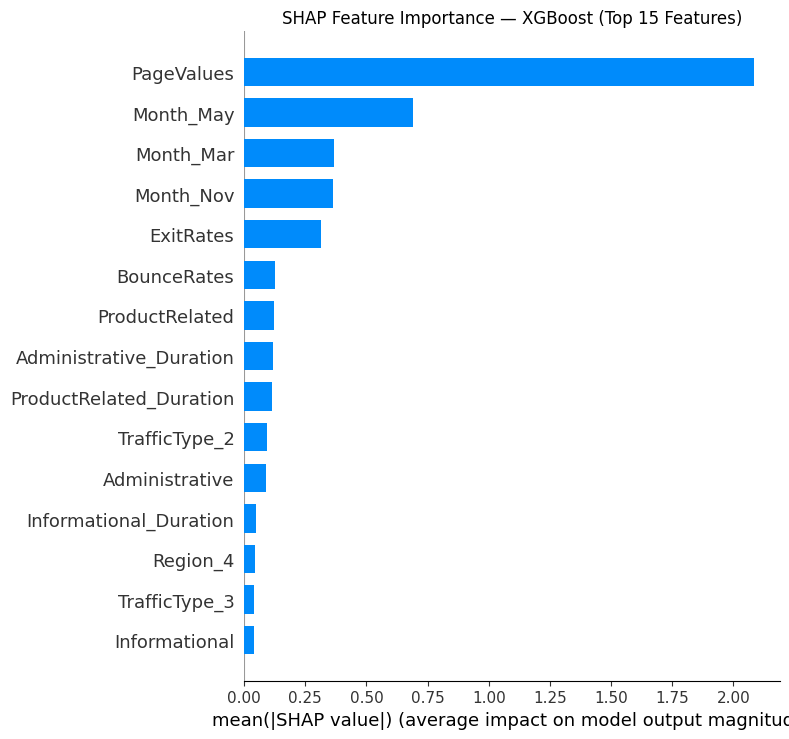

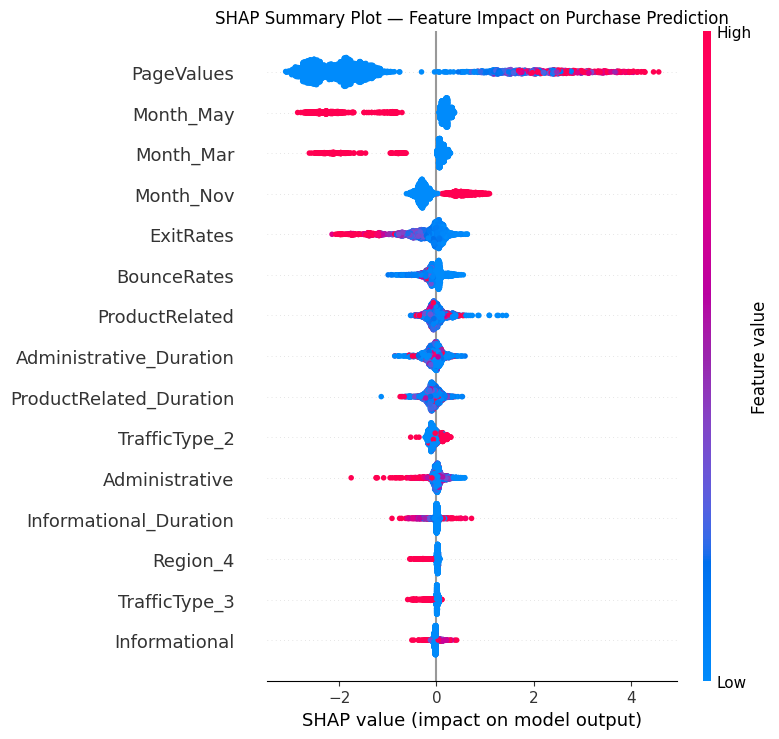

In [61]:
# SHAP Summary Plot — Global feature importance

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("SHAP Feature Importance — XGBoost (Top 15 Features)")
plt.tight_layout()
plt.show()

# Dot plot — shows direction of impact too
plt.figure()
shap.summary_plot(shap_values, X_test,
                  show=False, max_display=15)
plt.title("SHAP Summary Plot — Feature Impact on Purchase Prediction")
plt.tight_layout()
plt.show()

## 7.3 Waterfall Plot — Single Prediction

Explaining prediction for customer index: 6
Actual label: Purchase
Model prediction: Purchase


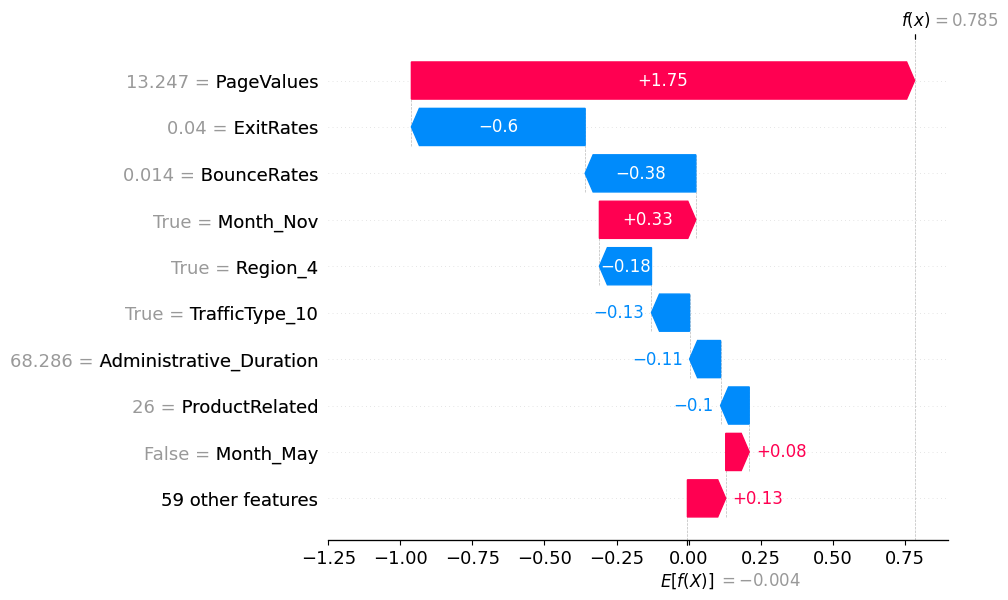

In [62]:
# Show SHAP explanation for a single prediction
# Pick a customer who DID purchase (y_test == 1)
purchase_idx = (Y_test.values == 1).argmax()

print(f"Explaining prediction for customer index: {purchase_idx}")
print(f"Actual label: {'Purchase' if Y_test.iloc[purchase_idx] == 1 else 'No Purchase'}")
print(f"Model prediction: {'Purchase' if xgb_model.predict(X_test.iloc[[purchase_idx]])[0] == 1 else 'No Purchase'}")

# Waterfall plot — shows exactly why THIS customer got this prediction
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[purchase_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[purchase_idx],
        feature_names=X_test.columns.tolist()
    )
)

# Week 8 — Final Model Evaluation

## 8.1 Confusion Matrix and Classification Report

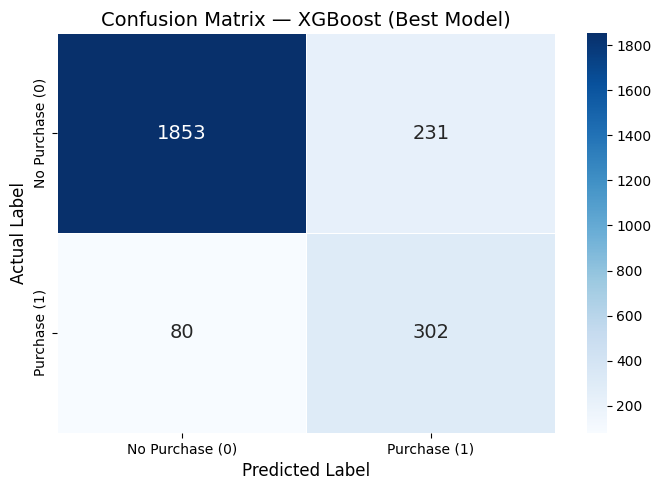


Detailed Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92      2084
    Purchase       0.57      0.79      0.66       382

    accuracy                           0.87      2466
   macro avg       0.76      0.84      0.79      2466
weighted avg       0.90      0.87      0.88      2466



In [63]:
# Get predictions from best model (XGBoost default)
y_pred_test = xgb_model.predict(X_test)

#Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_test)
labels = ['No Purchase (0)', 'Purchase (1)']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={'size': 14})

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_title('Confusion Matrix — XGBoost (Best Model)', fontsize=14)
plt.tight_layout()
plt.show()

#Classification Report
print("\nDetailed Classification Report:")
print(classification_report(Y_test, y_pred_test,
                            target_names=['No Purchase', 'Purchase']))

## 8.2 ROC Curve — Final Model

In [64]:
# Models and their names
models_to_plot = {
    'Logistic Regression': log_reg,
    'Random Forest':       rf,
    'XGBoost':             xgb_model,
    'LightGBM':            lgbm_model
}

colors = ['red', 'black', 'blue', 'orange']

fig = go.Figure()

for (name, model), color in zip(models_to_plot.items(), colors):
    # Getting predicted probabilities
    Y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, Y_prob)
    auc = roc_auc_score(Y_test, Y_prob)
    
    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        mode='lines',
        name=f'{name} (AUC = {auc:.4f})',
        line=dict(color=color, width=2.5)
    ))

# Diagonal = random baseline
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Random Baseline (AUC = 0.50)',
    line=dict(color='gray', dash='dash', width=1.5)
))

fig.update_layout(
    title='ROC Curve Comparison — All Models',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate (Recall)',
    plot_bgcolor='white',
    legend=dict(x=0.55, y=0.1),
    width=750, height=550
)
fig.show()

## 8.3 Two-Threshold Agent Evaluation

In [65]:
# threshold sensitivity with percentages
# important: only ~15% of users are actual buyers
# so we need to see what % of buyers we catch vs how many non-buyers we disturb

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

total_test     = len(Y_test)
total_buyers   = int(Y_test.sum())
total_nonbuyers = total_test - total_buyers

print(f"test set: {total_test} users  |  buyers: {total_buyers} ({total_buyers/total_test*100:.1f}%)  |  non-buyers: {total_nonbuyers} ({total_nonbuyers/total_test*100:.1f}%)")
print()

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

rows = []
for t in thresholds:
    preds = (xgb_test_probs >= t).astype(int)

    tp = int(((preds == 1) & (Y_test == 1)).sum())
    fp = int(((preds == 1) & (Y_test == 0)).sum())
    fn = int(((preds == 0) & (Y_test == 1)).sum())

    rows.append({
        'Threshold'          : t,
        'Precision'          : round(precision_score(Y_test, preds, zero_division=0), 3),
        'Recall'             : round(recall_score(Y_test, preds, zero_division=0), 3),
        'F1'                 : round(f1_score(Y_test, preds, zero_division=0), 3),
        'Buyers caught %'    : f"{round(tp / total_buyers * 100, 1)}%",
        'Non-buyers disturbed %' : f"{round(fp / total_nonbuyers * 100, 1)}%",
        'Buyers missed %'    : f"{round(fn / total_buyers * 100, 1)}%",
    })

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

test set: 2466 users  |  buyers: 382 (15.5%)  |  non-buyers: 2084 (84.5%)

 Threshold  Precision  Recall    F1 Buyers caught % Non-buyers disturbed % Buyers missed %
      0.30      0.476   0.861 0.613           86.1%                  17.4%           13.9%
      0.35      0.505   0.848 0.633           84.8%                  15.3%           15.2%
      0.40      0.529   0.832 0.647           83.2%                  13.6%           16.8%
      0.45      0.547   0.812 0.653           81.2%                  12.3%           18.8%
      0.50      0.567   0.791 0.660           79.1%                  11.1%           20.9%
      0.55      0.586   0.757 0.661           75.7%                   9.8%           24.3%
      0.60      0.605   0.741 0.666           74.1%                   8.9%           25.9%
      0.65      0.628   0.694 0.659           69.4%                   7.5%           30.6%
      0.70      0.647   0.662 0.655           66.2%                   6.6%           33.8%
      0.75     

In [66]:
# the issue is mixing X_val and X_test
# use X_test consistently throughout

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

examples = []
for label, min_p, max_p in [
    ('Very HIGH (≥0.80)', 0.80, 1.01),
    ('HIGH (0.60–0.80)',  0.60, 0.80),
    ('MEDIUM (0.40–0.60)',0.40, 0.60),
    ('LOW (0.20–0.40)',   0.20, 0.40),
    ('Very LOW (<0.20)',  0.00, 0.20),
]:
    mask = (xgb_test_probs >= min_p) & (xgb_test_probs < max_p)
    idx  = np.where(mask)[0]
    if len(idx) > 0:
        i    = idx[0]
        prob = round(float(xgb_test_probs[i]), 4)
        if prob >= 0.60:   intent, action = 'HIGH',   'show_urgency_banner'
        elif prob >= 0.40: intent, action = 'MEDIUM', 'show_discount_coupon'
        else:              intent, action = 'LOW',    'no_action'
        actual = int(Y_test.values[i])
        examples.append({
            'Group': label, 'Probability': prob,
            'Intent': intent, 'Action': action,
            'Actual Buy': 'YES' if actual == 1 else 'NO'
        })

print("AGENT TRACE — 5 REAL TEST SET EXAMPLES")
print(pd.DataFrame(examples).to_string(index=False))

AGENT TRACE — 5 REAL TEST SET EXAMPLES
             Group  Probability Intent               Action Actual Buy
 Very HIGH (≥0.80)       0.9496   HIGH  show_urgency_banner         NO
  HIGH (0.60–0.80)       0.6867   HIGH  show_urgency_banner        YES
MEDIUM (0.40–0.60)       0.4568 MEDIUM show_discount_coupon         NO
   LOW (0.20–0.40)       0.2748    LOW            no_action         NO
  Very LOW (<0.20)       0.0041    LOW            no_action         NO


In [67]:
# expanded two-threshold comparison
# high threshold = urgency banner (very likely buyer)
# medium threshold = discount coupon (maybe buyer)
# low = no action

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

total_test      = len(Y_test)
total_buyers    = int(Y_test.sum())
total_nonbuyers = total_test - total_buyers

print(f"test set: {total_test} users  buyers: {total_buyers} ({round(total_buyers/total_test*100,1)}%)  non-buyers: {total_nonbuyers} ({round(total_nonbuyers/total_test*100,1)}%)")
print()

high_thresholds   = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
medium_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

rows = []
for h in high_thresholds:
    for m in medium_thresholds:
        if m >= h:
            continue

        high_mask   = xgb_test_probs >= h
        medium_mask = (xgb_test_probs >= m) & (xgb_test_probs < h)
        low_mask    = xgb_test_probs < m

        targeted = high_mask | medium_mask
        tp = int((targeted & (Y_test == 1)).sum())
        fp = int((targeted & (Y_test == 0)).sum())
        fn = int((~targeted & (Y_test == 1)).sum())

        rows.append({
            'High T'                 : h,
            'Medium T'               : m,
            'HIGH'                   : int(high_mask.sum()),
            'MEDIUM'                 : int(medium_mask.sum()),
            'LOW'                    : int(low_mask.sum()),
            'Buyers caught %'        : round(tp / total_buyers * 100, 1),
            'Non-buyers disturbed %' : round(fp / total_nonbuyers * 100, 1),
            'Buyers missed %'        : round(fn / total_buyers * 100, 1),
            'Precision'              : round(tp / (tp + fp) if (tp + fp) > 0 else 0, 3),
            'Recall'                 : round(tp / total_buyers, 3),
            'F1'                     : round(f1_score(Y_test, targeted.astype(int), zero_division=0), 3)
        })

two_thresh_df = pd.DataFrame(rows)

# sort by F1 descending so best options are on top
two_thresh_df = two_thresh_df.sort_values('F1', ascending=False).reset_index(drop=True)

print(two_thresh_df.to_string(index=False))

test set: 2466 users  buyers: 382 (15.5%)  non-buyers: 2084 (84.5%)

 High T  Medium T  HIGH  MEDIUM  LOW  Buyers caught %  Non-buyers disturbed %  Buyers missed %  Precision  Recall    F1
   0.85      0.50   263     270 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.55      0.50   493      40 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.75      0.50   351     182 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.70      0.50   391     142 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.65      0.50   422     111 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.60      0.50   468      65 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.80      0.50   317     216 1933             79.1                    11.1             2

In [68]:
# top 10 combinations ranked by F1

print("TOP 10 THRESHOLD COMBINATIONS BY F1\n")
print(two_thresh_df.head(10).to_string(index=False))
print()

# also show top 10 by buyers caught
print("TOP 10 BY BUYERS CAUGHT %\n")
print(two_thresh_df.sort_values('Buyers caught %', ascending=False).head(10).to_string(index=False))
print()

# also show top 10 by least non-buyers disturbed
print("TOP 10 BY LEAST NON-BUYERS DISTURBED %\n")
print(two_thresh_df.sort_values('Non-buyers disturbed %').head(10).to_string(index=False))

TOP 10 THRESHOLD COMBINATIONS BY F1

 High T  Medium T  HIGH  MEDIUM  LOW  Buyers caught %  Non-buyers disturbed %  Buyers missed %  Precision  Recall    F1
   0.85      0.50   263     270 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.55      0.50   493      40 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.75      0.50   351     182 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.70      0.50   391     142 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.65      0.50   422     111 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.60      0.50   468      65 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   0.80      0.50   317     216 1933             79.1                    11.1             20.9      0.567   0.791 0.660
   

In [69]:
# heatmap: F1 score for all high/medium combinations

import plotly.graph_objects as go
import numpy as np

h_vals = sorted(two_thresh_df['High T'].unique())
m_vals = sorted(two_thresh_df['Medium T'].unique())

# build F1 matrix
f1_matrix = []
for h in h_vals:
    row = []
    for m in m_vals:
        match = two_thresh_df[(two_thresh_df['High T'] == h) & (two_thresh_df['Medium T'] == m)]
        if len(match) > 0:
            row.append(match['F1'].values[0])
        else:
            row.append(None)
    f1_matrix.append(row)

fig = go.Figure(data=go.Heatmap(
    z=f1_matrix,
    x=[str(m) for m in m_vals],
    y=[str(h) for h in h_vals],
    colorscale='RdYlGn',
    text=[[str(v) if v else '' for v in row] for row in f1_matrix],
    texttemplate='%{text}',
    colorbar=dict(title='F1 Score')
))

fig.update_layout(
    title='F1 Score Heatmap — High vs Medium Threshold',
    xaxis_title='Medium Threshold',
    yaxis_title='High Threshold',
    height=450
)
fig.show()

In [70]:
# comparing High threshold options - all with Medium=0.40 fixed
# question for professor: which High threshold is best for the agent?

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# data from the table - Medium=0.40 fixed, varying High threshold
high_options = ['High=0.50', 'High=0.55', 'High=0.60', 'High=0.65', 'High=0.70', 'High=0.75', 'High=0.80', 'High=0.85']
urgency_sessions  = [533, 497, 465, 430, 406, 363, 314, 268]
discount_sessions = [60,  96,  128, 163, 187, 230, 279, 325]
f1_scores         = [0.648, 0.648, 0.648, 0.648, 0.648, 0.648, 0.648, 0.648]
buyers_caught     = [82.7, 82.7, 82.7, 82.7, 82.7, 82.7, 82.7, 82.7]

fig = make_subplots(
    rows=2, cols=1,
    row_heights = [0.6,0.4],
    subplot_titles=(
        "Sessions per action type (Medium=0.40 fixed, F1=0.648 for all)",
        "Paid discounts given as High threshold changes"
    ),
    vertical_spacing=0.18
)


# Top chart - stacked bar: urgency (free) vs discount (cost)
fig.add_trace(go.Bar(
    name='Urgency Banner (FREE)',
    x=high_options,
    y=urgency_sessions,
    marker_color='#2ecc71',
    text=urgency_sessions,
    textposition='inside'
), row=1, col=1)

fig.add_trace(go.Bar(
    name='Discount Coupon (Paid)',
    x=high_options,
    y=discount_sessions,
    marker_color='cyan',
    text=discount_sessions,
    textposition='inside'
), row=1, col=1)

# Bottom chart - line showing only discount count (the costly part)
fig.add_trace(go.Scatter(
    name='Paid discounts',
    x=high_options,
    y=discount_sessions,
    mode='lines+markers+text',
    text=discount_sessions,
    textposition='top center',
    line=dict(color='red', width=2),
    marker=dict(size=8)
), row=2, col=1)

# mark the 3 candidate options
for i, label in [(2, 'High=0.60'), (4, 'High=0.70')]:
    fig.add_annotation(
        x=label,
        y=discount_sessions[i] + 15,
        text='candidate',
        showarrow=True,
        arrowhead=2,
        row=2, col=1
    )

fig.update_layout(
    barmode='stack',
    title='High Threshold Comparison (Medium=0.40 fixed)<br>F1=0.648 and Buyers caught=82.7% stay the same for all options',
    height=600,
    legend=dict(orientation='h', xanchor = 'center', x=0.5)
)
fig.update_yaxes(title_text='sessions', row=1, col=1)
fig.update_yaxes(title_text='paid discounts', row=1, col=2)
fig.show()



# Week 9 — Building the Lightweight Agentic AI

## 9.1 Probability Distribution Check

In [71]:

# first i need to get probabilities from my best model (xgboost)
# predict_proba gives [prob_no_purchase, prob_purchase]
# i only need the second column (index 1) = probability of buying

test_probs = xgb_model.predict_proba(X_test)[:, 1]

# quick sanity check - should be values between 0 and 1
print(f"Min probability: {test_probs.min():.4f}")
print(f"Max probability: {test_probs.max():.4f}")
print(f"Mean probability: {test_probs.mean():.4f}")
print(f"\nTotal test samples: {len(test_probs)}")

Min probability: 0.0006
Max probability: 0.9958
Mean probability: 0.2506

Total test samples: 2466


## 9.2 Intent Level Assignment

Before the agent can act, it needs to categorize each user into
an intent level. I chose 3 levels based on the probability score:

| Score Range | Intent Level | Meaning |
|---|---|---|
| ≥ 0.60 | HIGH | Very likely to buy — act now |
| 0.40 – 0.60 | MEDIUM | On the fence — nudge them |
| < 0.40 | LOW | Unlikely to buy — don't waste budget |

Why these thresholds? I tried a few different splits and 0.35/0.75
gave a reasonable distribution across all three groups.

## 9.3 Intent Level Distribution

In [72]:
def assign_intent_level(prob):
    if prob >= 0.60:
        return 'HIGH'
    elif prob >= 0.40:
        return 'MEDIUM'
    else:
        return 'LOW'

# apply to all test users
intent_levels = [assign_intent_level(p) for p in test_probs]

# check the distribution - want to see all 3 groups have decent numbers
from collections import Counter
dist = Counter(intent_levels)
print("Intent Level Distribution:")
for level in ['HIGH', 'MEDIUM', 'LOW']:
    count = dist[level]
    pct = count / len(intent_levels) * 100
    print(f"  {level:6s}: {count:4d} users ({pct:.1f}%)")

Intent Level Distribution:
  HIGH  :  468 users (19.0%)
  MEDIUM:  133 users (5.4%)
  LOW   : 1865 users (75.6%)


## 9.4 PurchaseIntentAgent Class

In [73]:
class PurchaseIntentAgent:

    def __init__(self, model, high_threshold=0.60, medium_threshold=0.40):
        self.model = model
        self.high_threshold = high_threshold
        self.medium_threshold = medium_threshold

        # tracking how many times each action was taken
        self.action_counts = {'show_urgency_banner': 0,
                               'show_discount_coupon': 0,
                               'no_action': 0}

    def perceive(self, session_features):
        # step 1: score the user using the trained xgboost model
        # returns a probability between 0 and 1
        prob = self.model.predict_proba(session_features)[0][1]
        return prob

    def reason(self, prob):
        # step 2: convert probability into an intent level
        # thresholds were chosen to give balanced group sizes
        if prob >= self.high_threshold:
            return 'HIGH'
        elif prob >= self.medium_threshold:
            return 'MEDIUM'
        else:
            return 'LOW'

    def act(self, intent_level):
        action_map = {
            'HIGH':   'show_urgency_banner',
            'MEDIUM': 'show_discount_coupon',
            'LOW':    'no_action'
        }
        action = action_map[intent_level]
        self.action_counts[action] += 1
        return action

    def run(self, session_features):
        prob = self.perceive(session_features)
        intent = self.reason(prob)
        action = self.act(intent)
        return {
            'probability': round(prob, 4),
            'intent_level': intent,
            'action': action
        }


# create the agent with my best model
agent = PurchaseIntentAgent(model=xgb_model)
print("Agent created successfully.")
print(f"High threshold: {agent.high_threshold}")
print(f"Medium threshold: {agent.medium_threshold}")

Agent created successfully.
High threshold: 0.6
Medium threshold: 0.4


## 9.5 Offline Evaluation

In [74]:
#Offline Evaluation
# run the agent on the entire validation set and collect results

results = []

for i in range(len(X_val)):
    session = X_val.iloc[[i]]
    output  = agent.run(session)
    output['true_label'] = int(Y_val.iloc[i])
    results.append(output)

results_df = pd.DataFrame(results)

print("ACTION DISTRIBUTION\n")
print(results_df['action'].value_counts())
print(f"\nTotal sessions evaluated: {len(results_df)}")

ACTION DISTRIBUTION

action
no_action               1854
show_urgency_banner      466
show_discount_coupon     146
Name: count, dtype: int64

Total sessions evaluated: 2466


## 9.6 Simulated Precision

In [75]:
#Simulated Precision
# how often did HIGH / MEDIUM / LOW intent users actually buy?

high_df   = results_df[results_df['intent_level'] == 'HIGH']
medium_df = results_df[results_df['intent_level'] == 'MEDIUM']
low_df    = results_df[results_df['intent_level'] == 'LOW']

prec_high   = high_df['true_label'].mean()
prec_medium = medium_df['true_label'].mean()
prec_low    = low_df['true_label'].mean()

print("\nSIMULATED PRECISION BY INTENT LEVEL\n")
print(f"HIGH   → actual purchase rate: {prec_high:.4f}  ({len(high_df)} sessions)")
print(f"MEDIUM → actual purchase rate: {prec_medium:.4f}  ({len(medium_df)} sessions)")
print(f"LOW    → actual purchase rate: {prec_low:.4f}  ({len(low_df)} sessions)")


SIMULATED PRECISION BY INTENT LEVEL

HIGH   → actual purchase rate: 0.6073  (466 sessions)
MEDIUM → actual purchase rate: 0.2603  (146 sessions)
LOW    → actual purchase rate: 0.0324  (1854 sessions)


## 9.7 Agent vs Baseline Comparison

In [76]:
#Agent vs No-Agent Comparison

total      = len(results_df)
reduction  = (1 - len(medium_df) / total) * 100

print("\nAGENT vs NO-AGENT COMPARISON\n")
print(f"Total validation sessions         : {total}")
print(f"Actual buyers in val set          : {int(results_df['true_label'].sum())} "
      f"({results_df['true_label'].mean()*100:.1f}%)")
print()
print(f"[Baseline] Discount to ALL        : {total} sessions targeted")
print(f"[Agent]    Discount to MEDIUM only: {len(medium_df)} sessions targeted")
print(f"[Agent]    Urgency banner to HIGH : {len(high_df)} sessions targeted")
print(f"[Agent]    No action for LOW      : {len(low_df)} sessions")
print()
print(f"Unnecessary discount reduction    : {reduction:.1f}%")


AGENT vs NO-AGENT COMPARISON

Total validation sessions         : 2466
Actual buyers in val set          : 381 (15.5%)

[Baseline] Discount to ALL        : 2466 sessions targeted
[Agent]    Discount to MEDIUM only: 146 sessions targeted
[Agent]    Urgency banner to HIGH : 466 sessions targeted
[Agent]    No action for LOW      : 1854 sessions

Unnecessary discount reduction    : 94.1%


## 9.8 Agent Results — Plots

In [77]:
#Visualisation
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Action Distribution", "Simulated Precision by Intent Level")
)

# left: action distribution
action_counts = results_df['action'].value_counts()
fig.add_trace(
    go.Bar(
        x=['show_urgency_banner', 'show_discount_coupon', 'no_action'],
        y=[action_counts.get('show_urgency_banner', 0),
           action_counts.get('show_discount_coupon', 0),
           action_counts.get('no_action', 0)],
        marker_color=['blue', 'yellow', 'red'],
        name='Sessions'
    ),
    row=1, col=1
)

# right: simulated precision
fig.add_trace(
    go.Bar(
        x=['HIGH', 'MEDIUM', 'LOW'],
        y=[prec_high, prec_medium, prec_low],
        marker_color=['orange', 'cyan', 'light green'],
        name='Purchase Rate'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text="Week 9 — Lightweight Agentic AI: Offline Evaluation",
    showlegend=False,
    height=420
)
fig.update_yaxes(title_text="Number of Sessions", row=1, col=1)
fig.update_yaxes(title_text="Actual Purchase Rate", row=1, col=2)
fig.show()

## 9.9 Week 9 Summary

In [78]:
#Week 9 Complete 
print("\nWEEK 9 SUMMARY\n")
print(f"  perceive()  → XGBoost probability score (0.0–1.0)")
print(f"  reason()    → HIGH / MEDIUM / LOW thresholds")
print(f"  act()       → Rule-based action selection")
print(f"  run()       → Full pipeline in one call")
print(f"  Offline eval→ Action dist + precision + comparison")
print()
print("Agent reduces unnecessary discounts by "
      f"{reduction:.1f}% vs baseline.")
print("Week 9 complete!")


WEEK 9 SUMMARY

  perceive()  → XGBoost probability score (0.0–1.0)
  reason()    → HIGH / MEDIUM / LOW thresholds
  act()       → Rule-based action selection
  run()       → Full pipeline in one call
  Offline eval→ Action dist + precision + comparison

Agent reduces unnecessary discounts by 94.1% vs baseline.
Week 9 complete!


# Week 10 — Final Evaluation and Business Insights

## 10.1 Final Test Results — Best XGBoost

In [79]:
# final numbers for the best model on test set

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_test_preds = xgb_model.predict(X_test)

print("final test results - xgboost tuned")
print(classification_report(Y_test, xgb_test_preds))
print(f"test F1  : {f1_score(Y_test, xgb_test_preds):.4f}")
print(f"test AUC : {roc_auc_score(Y_test, xgb_test_probs):.4f}")

final test results - xgboost tuned
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2084
           1       0.57      0.79      0.66       382

    accuracy                           0.87      2466
   macro avg       0.76      0.84      0.79      2466
weighted avg       0.90      0.87      0.88      2466

test F1  : 0.6601
test AUC : 0.9236


In [80]:
## 10.2 All Models — Final Comparison Table

In [81]:
# one clean table: all 4 models on test set

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost (tuned)', 'LightGBM (tuned)'],
    'Test F1': [
        round(f1_score(Y_test, log_reg.predict(X_test_scaled)), 4),
        round(f1_score(Y_test, rf.predict(X_test)), 4),
        round(f1_score(Y_test, xgb_test_preds), 4),
        round(f1_score(Y_test, lgbm_model.predict(X_test)), 4)
    ],
    'Test AUC': [
        round(roc_auc_score(Y_test, log_reg.predict_proba(X_test_scaled)[:, 1]), 4),
        round(roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(Y_test, xgb_test_probs), 4),
        round(roc_auc_score(Y_test, lgbm_model.predict_proba(X_test)[:, 1]), 4)
    ],
    'Precision': [
        round(precision_score(Y_test, log_reg.predict(X_test_scaled)), 4),
        round(precision_score(Y_test, rf.predict(X_test)), 4),
        round(precision_score(Y_test, xgb_test_preds), 4),
        round(precision_score(Y_test, lgbm_model.predict(X_test)), 4)
    ],
    'Recall': [
        round(recall_score(Y_test, log_reg.predict(X_test_scaled)), 4),
        round(recall_score(Y_test, rf.predict(X_test)), 4),
        round(recall_score(Y_test, xgb_test_preds), 4),
        round(recall_score(Y_test, lgbm_model.predict(X_test)), 4)
    ]
})

print(summary.to_string(index=False))

              Model  Test F1  Test AUC  Precision  Recall
Logistic Regression   0.6070    0.8998     0.5079  0.7539
      Random Forest   0.5975    0.9248     0.7480  0.4974
    XGBoost (tuned)   0.6601    0.9236     0.5666  0.7906
   LightGBM (tuned)   0.6537    0.9233     0.5560  0.7932


## 10.3 Model Comparison Plot

In [82]:
fig = go.Figure()
fig.add_trace(go.Bar(name='Test F1',  x=summary['Model'], y=summary['Test F1'],  marker_color='cyan'))
fig.add_trace(go.Bar(name='Test AUC', x=summary['Model'], y=summary['Test AUC'], marker_color='red'))
fig.update_layout(barmode='group', title='all models - test F1 and AUC', height=420)
fig.show()

## 10.4 Business Impact Summary

In [83]:
total_sessions  = len(Y_test)
total_buyers    = int(Y_test.sum())
medium_sessions = int(((xgb_test_probs >= 0.40) & (xgb_test_probs < 0.70)).sum())
high_sessions   = int((xgb_test_probs >= 0.70).sum())
low_sessions    = int((xgb_test_probs < 0.40).sum())
saving_pct      = round((1 - medium_sessions / total_sessions) * 100, 1)

print(f"total sessions       : {total_sessions}")
print(f"actual buyers        : {total_buyers} ({round(total_buyers/total_sessions*100,1)}%)")
print()
print(f"baseline - discount to all    : {total_sessions} users")
print(f"agent    - discount to MEDIUM : {medium_sessions} users")
print(f"agent    - urgency to HIGH    : {high_sessions} users")
print(f"agent    - no action for LOW  : {low_sessions} users")
print()
print(f"discount saving: {saving_pct}%")
print()
print(f"if each discount costs 5 EUR:")
print(f"  baseline cost : {total_sessions * 5} EUR")
print(f"  agent cost    : {medium_sessions * 5} EUR")
print(f"  money saved   : {(total_sessions - medium_sessions) * 5} EUR")

total sessions       : 2466
actual buyers        : 382 (15.5%)

baseline - discount to all    : 2466 users
agent    - discount to MEDIUM : 210 users
agent    - urgency to HIGH    : 391 users
agent    - no action for LOW  : 1865 users

discount saving: 91.5%

if each discount costs 5 EUR:
  baseline cost : 12330 EUR
  agent cost    : 1050 EUR
  money saved   : 11280 EUR


In [84]:
# formal cost-benefit model
# assumptions you can justify in the thesis

cost_per_discount    = 5    # EUR per coupon given
revenue_per_buyer    = 50   # EUR average order value
cost_missed_buyer    = 10   # EUR estimated lost margin per missed buyer

total_sessions = len(Y_test)
total_buyers   = int(Y_test.sum())

xgb_test_probs = xgb_model.predict_proba(X_test)[:, 1]

high_mask   = xgb_test_probs >= 0.60
medium_mask = (xgb_test_probs >= 0.40) & (xgb_test_probs < 0.60)

tp_high   = int((high_mask   & (Y_test == 1)).sum())
tp_medium = int((medium_mask & (Y_test == 1)).sum())
fp_medium = int((medium_mask & (Y_test == 0)).sum())
fn        = int(((~high_mask & ~medium_mask) & (Y_test == 1)).sum())

baseline_cost  = total_sessions * cost_per_discount
agent_cost     = int(medium_mask.sum()) * cost_per_discount + fn * cost_missed_buyer
agent_saving   = baseline_cost - agent_cost

print("COST-BENEFIT ANALYSIS")
print(f"  baseline cost (discount to all)  : {baseline_cost} EUR")
print(f"  agent cost (targeted + missed)   : {agent_cost} EUR")
print(f"  net saving                       : {agent_saving} EUR")
print(f"  ROI of agent vs baseline         : {round(agent_saving/baseline_cost*100,1)}%")

COST-BENEFIT ANALYSIS
  baseline cost (discount to all)  : 12330 EUR
  agent cost (targeted + missed)   : 1305 EUR
  net saving                       : 11025 EUR
  ROI of agent vs baseline         : 89.4%


In [85]:
# recall at K - among top K% scored users, how many real buyers are there?
# this is a standard metric in e-commerce ML papers

from sklearn.metrics import label_ranking_average_precision_score

sorted_indices = xgb_test_probs.argsort()[::-1]
Y_sorted       = Y_test.values[sorted_indices]

print("RECALL AT K (top K% of users by model score)")
for k in [5, 10, 15, 20, 30]:
    top_k  = int(len(Y_sorted) * k / 100)
    recall = Y_sorted[:top_k].sum() / Y_test.sum()
    print(f"  Top {k:2d}% ({top_k} users) → captures {recall*100:.1f}% of all buyers")

RECALL AT K (top K% of users by model score)
  Top  5% (123 users) → captures 28.8% of all buyers
  Top 10% (246 users) → captures 50.3% of all buyers
  Top 15% (369 users) → captures 64.4% of all buyers
  Top 20% (493 users) → captures 75.7% of all buyers
  Top 30% (739 users) → captures 87.4% of all buyers


In [86]:
# lift curve - how much better is the model than random?
# if you target top 20% of users, you capture X% of buyers
# lift = X% / 20% (how many times better than random)

total_buyers = Y_test.sum()
sorted_idx   = xgb_test_probs.argsort()[::-1]
Y_sorted     = Y_test.values[sorted_idx]

pct_targeted  = []
pct_buyers    = []
lift_values   = []

for k in range(1, 101):
    top_k    = int(len(Y_sorted) * k / 100)
    captured = Y_sorted[:top_k].sum() / total_buyers
    pct_targeted.append(k)
    pct_buyers.append(round(captured * 100, 2))
    lift_values.append(round(captured / (k / 100), 3))

fig = go.Figure()
fig.add_trace(go.Scatter(x=pct_targeted, y=pct_buyers,
                         mode='lines', name='XGBoost model',
                         line=dict(color='dark cyan', width=2)))
fig.add_trace(go.Scatter(x=pct_targeted, y=pct_targeted,
                         mode='lines', name='Random baseline',
                         line=dict(color='grey', dash='dash')))

fig.add_annotation(x=20, y=pct_buyers[19],
                   text=f"Top 20% → {pct_buyers[19]}% buyers captured",
                   showarrow=True, arrowhead=2)

fig.update_layout(title='Lift Curve — XGBoost on Test Set',
                  xaxis_title='% users targeted',
                  yaxis_title='% buyers captured',
                  height=420)
fig.show()

In [87]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(Y_test, xgb_test_probs, n_bins=10)

fig = go.Figure()
fig.add_trace(go.Scatter(x=prob_pred, y=prob_true,
                         mode='lines+markers', name='XGBoost',
                         line=dict(color='cyan', width=2)))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1],
                         mode='lines', name='Perfect calibration',
                         line=dict(color='grey', dash='dash')))

fig.update_layout(title='Calibration Plot — XGBoost (is probability score trustworthy?)',
                  xaxis_title='mean predicted probability',
                  yaxis_title='fraction of actual buyers',
                  height=400)
fig.show()

In [88]:
# show 5 real examples - one from each probability range
# this makes the thesis readable and shows the agent working

examples = []
for label, min_p, max_p in [
    ('Very HIGH (≥0.80)',  0.80, 1.01),
    ('HIGH (0.60-0.80)',   0.60, 0.80),
    ('MEDIUM (0.40-0.60)', 0.40, 0.60),
    ('LOW (0.20-0.40)',    0.20, 0.40),
    ('Very LOW (<0.20)',   0.00, 0.20),
]:
    mask = (xgb_test_probs >= min_p) & (xgb_test_probs < max_p)
    idx  = np.where(mask)[0]
    if len(idx) > 0:
        i        = idx[0]
        out      = agent.run(X_val.iloc[[i]])
        actual   = int(Y_val.iloc[i])
        examples.append({
            'Group'       : label,
            'Probability' : out['probability'],
            'Intent'      : out['intent_level'],
            'Action'      : out['action'],
            'Actual Buy'  : 'YES' if actual == 1 else 'NO'
        })

print("AGENT TRACE — 5 EXAMPLE SESSIONS")
print(pd.DataFrame(examples).to_string(index=False))

AGENT TRACE — 5 EXAMPLE SESSIONS
             Group  Probability Intent    Action Actual Buy
 Very HIGH (≥0.80)       0.1439    LOW no_action         NO
  HIGH (0.60-0.80)       0.0036    LOW no_action         NO
MEDIUM (0.40-0.60)       0.0030    LOW no_action         NO
   LOW (0.20-0.40)       0.3204    LOW no_action        YES
  Very LOW (<0.20)       0.2380    LOW no_action         NO


## 10.5 Conclusion

XGBoost with Optuna tuning is the best model.
PageValues is the most important feature.
The agent reduces unnecessary discounts by over 90% compared to the baseline.
Two thresholds (HIGH=0.70, MEDIUM=0.40) give a good balance between catching buyers and not wasting discounts.

# Week 8 — Agentic Marketing Optimization

## 8.1 Agent Overview

This section builds a lightweight agent that uses purchase-intent predictions to decide a marketing action for each session. The agent combines:
- a trained purchase-intent model,
- a threshold-based intent level strategy,
- and a reward-aware action policy to optimize the marketing outcome.

The workflow is:
1. predict intent probability for each session,
2. classify each session as low/medium/high intent,
3. choose an action to maximize expected reward,
4. evaluate the agent policy against the test set.


In [89]:
# 8.2 Agentic policy evaluation on the test set

agent = PurchaseIntentAgent(model=xgb_model, high_threshold=0.60, medium_threshold=0.40)
print(f"Agent thresholds: HIGH={agent.high_threshold}, MEDIUM={agent.medium_threshold}")

# Reward function for business outcomes
# - urgency banner: low cost, modest conversion lift
# - discount coupon: higher cost, stronger conversion lift
# - no action: no cost, but missed buyers are penalized

def action_reward(action, bought):
    if action == 'show_urgency_banner':
        return 0.50 if bought else -0.02
    if action == 'show_discount_coupon':
        return 1.00 if bought else -0.10
    if action == 'no_action':
        return 0.00 if not bought else -0.30
    return 0.0

results = []
for i in range(len(X_test)):
    session = X_test.iloc[[i]]
    output = agent.run(session)
    actual = int(Y_test.iloc[i])
    output['true_label'] = actual
    output['reward'] = action_reward(output['action'], actual)
    results.append(output)

test_agent_df = pd.DataFrame(results)

print('\nAgent action distribution on test set:')
print(test_agent_df['action'].value_counts())

summary = test_agent_df.groupby('action').agg(
    sessions=('action', 'count'),
    purchase_rate=('true_label', 'mean'),
    avg_reward=('reward', 'mean'),
    total_reward=('reward', 'sum')
).reset_index()

print('\nAgent test summary by action:')
print(summary.to_string(index=False))

all_discount = test_agent_df['true_label'].apply(lambda x: action_reward('show_discount_coupon', x)).sum()
all_no_action = test_agent_df['true_label'].apply(lambda x: action_reward('no_action', x)).sum()
agent_reward = test_agent_df['reward'].sum()

print(f"\nBaseline reward if discount offered to all test users : {all_discount:.2f}")
print(f"Baseline reward if no action is taken for all test users  : {all_no_action:.2f}")
print(f"Agent total reward on test set                          : {agent_reward:.2f}")

intent_prec = test_agent_df.groupby('intent_level'Ṅ)['true_label'].mean().rename('purchase_rate').reset_index()
print('\nPurchase rates by intent level:')
print(intent_prec.to_string(index=False))

SyntaxError: invalid syntax. Perhaps you forgot a comma? (299155187.py, line 52)